# Class Balance 

In this notebook, we evaluate interventions on the class inbalance for our current training pipeline. A good intervention should lead to better result on underrepresented classes while not worsen the results on classes that appear more often.

We think that the class inbalance we observed in the [Exploratory Data Analysis](00_exploratory_data_analysis.ipynb), is one big reason why our **mAP** on the test set is much lower than the **mAP** on the validation set.

For each intervention, we reinitialize the embedding projection model and monitor the **identity-balanced mAP** on the validation set.

We use the results from our previous notebooks for the training pipeline:
- **Blurred backgrounds** (see [Background Interventions Notebook](01_background_interventions.ipynb))
- **DINOv3** backbone (see [Backbone Notebook](02_backbone.ipynb))
- Combined **ProxyAnchor + Center Loss** (see [Loss Combined Notebook](04_loss_combined.ipynb))
- **AdamW** optimizer (see [Optimizer Notebook](05_optimizers.ipynb))
- **CosineAnnealingLR** scheduler (see [Scheduler Notebook](06_scheduler.ipynb))

The notebook is structured as follows:

1. **Baseline**
2. **Weighted Sampling**
3. **Generate Augmented Samples**
4. **Weighted Sampling + Augmentation**

## 1. Setup and Configuration

This section defines the required imports and configuration settings used throughout the notebook. These include library dependencies and any global parameters.

In [ ]:
EXPERIMENT_NAME = "07_class_balancing"
RANDOM_SEED = 35 # 2, 35, 78, 56, 432

# -----------------------------
# Environment setup
# -----------------------------
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# -----------------------------
# Standard library imports
# -----------------------------
from dotenv import load_dotenv
from pathlib import Path
import random
import sys
import time

# -----------------------------
# Third-party libraries
# -----------------------------
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
from tqdm import tqdm
import torch
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms

from tqdm import tqdm
import wandb

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# -----------------------------
# Project path setup
# -----------------------------
PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

# -----------------------------
# Local modules
# -----------------------------
from src.criterions import (
    CenterLoss,
    CombinedLoss,
    ProxyAnchorLoss,
)
from src.datasets import BlurImageDataset, EmbeddingDataset, ImageDataset
from src.models import EmbeddingProjection
from src.training import train_loop
from src.utils import (
    create_deterministic_training_dataloader,
    get_device,
    set_seeds,
    extract_embeddings, get_embeddings,
)
from src.visualization import (
    plot_history,
    visualize_embeddings_mds,
    visualize_nearest_neighbors,
)

# -----------------------------
# Reproducibility
# -----------------------------
set_seeds(RANDOM_SEED)
print(f"PyTorch version: {torch.__version__}")

Define shared paths for the whole project.

In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [ ]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    "proxyanchor_lambda": 0.0005,
    
    # Optimizer
    "init_learning_rate": 5e-3,
    "eta_min": 1e-5,
    "weight_decay": 1e-4,

    # Training
    "batch_size": 32,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Generate Augmentations
    # One could try to increase this number, but this will increase runtime and training time
    "min_images_per_identity": 50,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  proxyanchor_lambda: 0.0005
  init_learning_rate: 0.005
  eta_min: 1e-05
  weight_decay: 0.0001
  batch_size: 32
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 35


In [ ]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project=os.getenv("WANDB_PROJECT", "jaguar-reid-karl-matti-schuetz"),
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


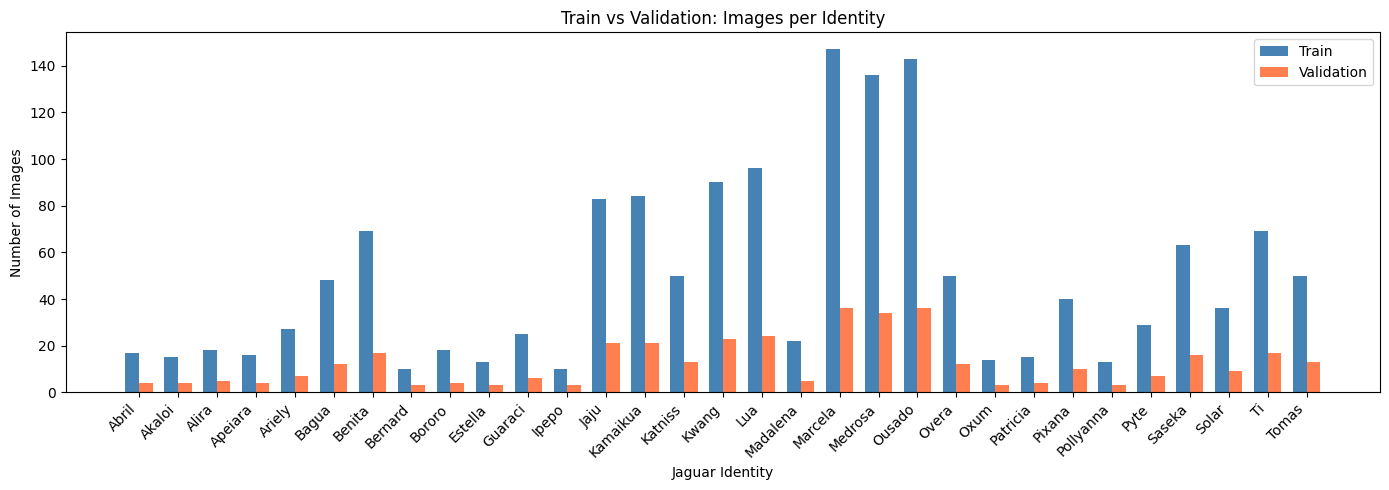


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [ ]:
device = get_device()
print(f"Using device: {device}")

num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using CUDA GPU
Using device: cuda


In [ ]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = np.array([DATA_PATH / "train" / fn for fn in filenames])

train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [ ]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")
    
wandb.log({
    "dino_num_params": dino_num_params,
    "dino_embedding_dim": dino_dim,
    "dino_input_size": dino_config["input_size"],
    "dino_preprocessing": str(dino_config),
})

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [ ]:
image_dataset = BlurImageDataset(
    image_paths,
    preprocess_fn=dino_preprocess
)
image_loader = DataLoader(
    image_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [ ]:
baseline_cache_path = OUTPUT_PATH_SHARED / "dino_blur_embeddings.npz"

baseline_embeddings = get_embeddings(
    model=dino,
    cache_path=baseline_cache_path,
    data_loader=image_loader,
    filenames=filenames,
    device=device
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/shared/dino_blur_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


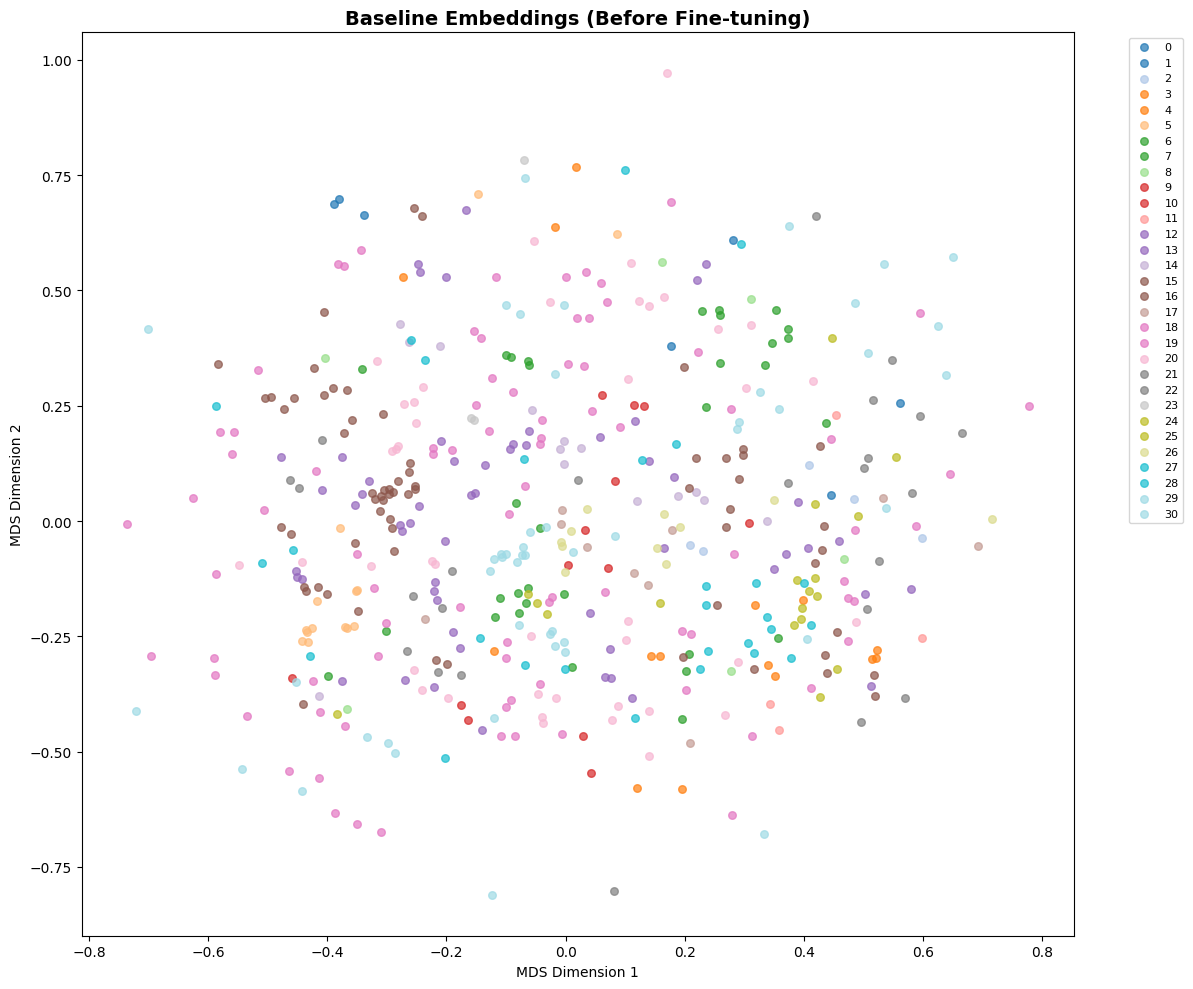

In [14]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [15]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [ ]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

wandb.log({"num_projection_params": sum(p.numel() for p in model.parameters())})

model.print_model_summary()

Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592


During comparison, we initialize each experiment with the same model weights to ensure that differences in performance are not influenced by variations in initialization.

In [17]:
# Export initial model weights for reinitialization
initial_weights_path = CHECKPOINT_PATH / "model_initial_weights.pth"
torch.save(model.state_dict(), initial_weights_path)
print(f"Initial model weights saved to {initial_weights_path}")

Initial model weights saved to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/balancing/model_initial_weights.pth


Since Loss includes learnable proxy vectors, these vectors must be reset before retraining the embedding projection model.

In [ ]:
criterion = CombinedLoss(
    first_loss=CenterLoss(
        num_classes=num_classes, 
        embedding_dim=config["embedding_dim"]
    ),
    second_loss=ProxyAnchorLoss(
        num_classes=num_classes, 
        embedding_dim=config["embedding_dim"], 
        margin=config["proxyanchor_margin"], 
        alpha=config["proxyanchor_alpha"]
    ),
    lambda_center=config["proxyanchor_lambda"]
).to(device)

print(f"Combined Loss: CenterLoss + ProxyAnchor")
print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")
print(f"  Lambda: {config['proxyanchor_lambda']}")

In [ ]:
criterion_checkpoint_path = CHECKPOINT_PATH / "criterion_initial_state.pth"
torch.save(criterion.state_dict(), criterion_checkpoint_path)
print(f"Initial criterion state saved to {criterion_checkpoint_path}")

In [ ]:
table = [
    ["Scheduler", "Best val_mAP", "Best epoch", "Training time"]
]

## Baseline

In the baseline, the dataset is kept unchanged and unbalanced. This is necessary for later comparison.

In [20]:
baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
    
)

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path, map_location=device))
criterion.load_state_dict(torch.load(criterion_checkpoint_path, map_location=device))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config["num_epochs"],
    eta_min=config["eta_min"]
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss + CenterLoss")
print(f"  Optimizer: AdamW (lr={config['init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: CosineAnnealingLR (T_max={config['num_epochs']}, eta_min={config['eta_min']})")

Training components initialized:
  Loss: ProxyAnchorLoss + CenterLoss
  Optimizer: AdamW (lr=0.005, weight_decay=0.0001)
  Scheduler: CosineAnnealingLR (T_max=200, eta_min=1e-05)


In [ ]:
# Training loop
set_seeds(config['seed'])
baseline_checkpoint_path = CHECKPOINT_PATH / "best_model_baseline.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="baseline",
    checkpoint_path=baseline_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_baseline": best_map,
    "best_epoch_baseline": best_epoch,
    "total_epochs_baseline": len(history['train_loss']),
    "training_time_baseline": training_time
})

table.append([
    "Baseline",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 35 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 8.2444
  Val Loss:   6.0108
  Val mAP:    0.2621 | LR: 5.00e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 5.0197
  Val Loss:   2.1675
  Val mAP:    0.3737 | LR: 5.00e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 2.4164
  Val Loss:   1.7141
  Val mAP:    0.5780 | LR: 5.00e-03
  [New best model saved]

Epoch 4/200


  Train Loss: 1.7815
  Val Loss:   1.4077
  Val mAP:    0.7155 | LR: 5.00e-03
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1559
  Val Loss:   0.9458
  Val mAP:    0.8725 | LR: 4.79e-03
  No improvement. Patience: 6/10

Epoch 27/200


  Train Loss: 0.1578
  Val Loss:   0.9670
  Val mAP:    0.8694 | LR: 4.78e-03
  No improvement. Patience: 7/10

Epoch 28/200


  Train Loss: 0.1488
  Val Loss:   0.9153
  Val mAP:    0.8722 | LR: 4.76e-03
  No improvement. Patience: 8/10

Epoch 29/200


  Train Loss: 0.1668
  Val Loss:   1.0085
  Val mAP:    0.8695 | LR: 4.75e-03
  No improvement. Patience: 9/10

Epoch 30/200


  Train Loss: 0.1763
  Val Loss:   0.9395
  Val mAP:    0.8662 | LR: 4.73e-03
  No improvement. Patience: 10/10

Early stopping triggered after 30 epochs

Training complete!
Best epoch: 20, Val mAP: 0.8873


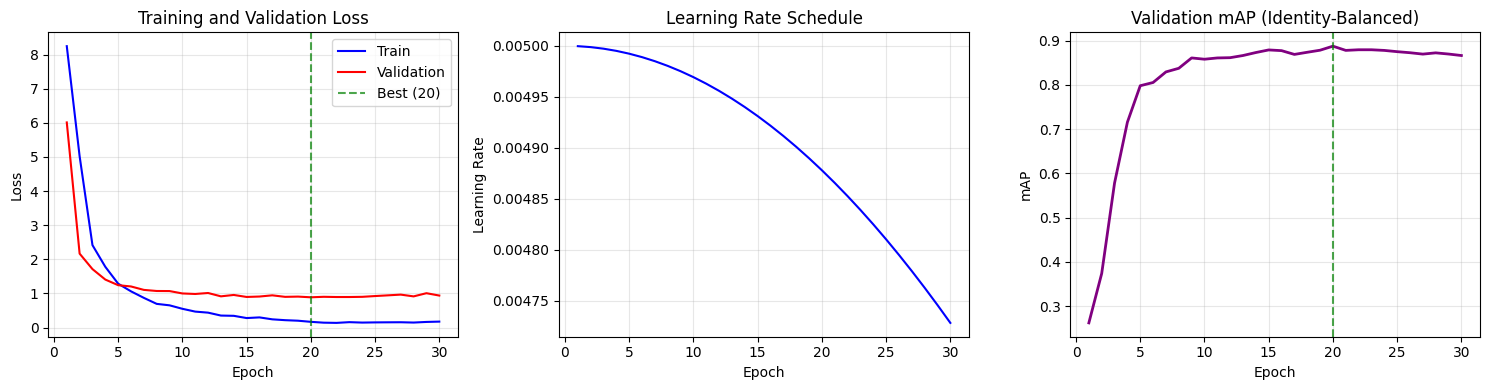

In [23]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_baseline": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(baseline_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 20
  Val Loss: 0.8887
  Val mAP: 0.8873


In [25]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


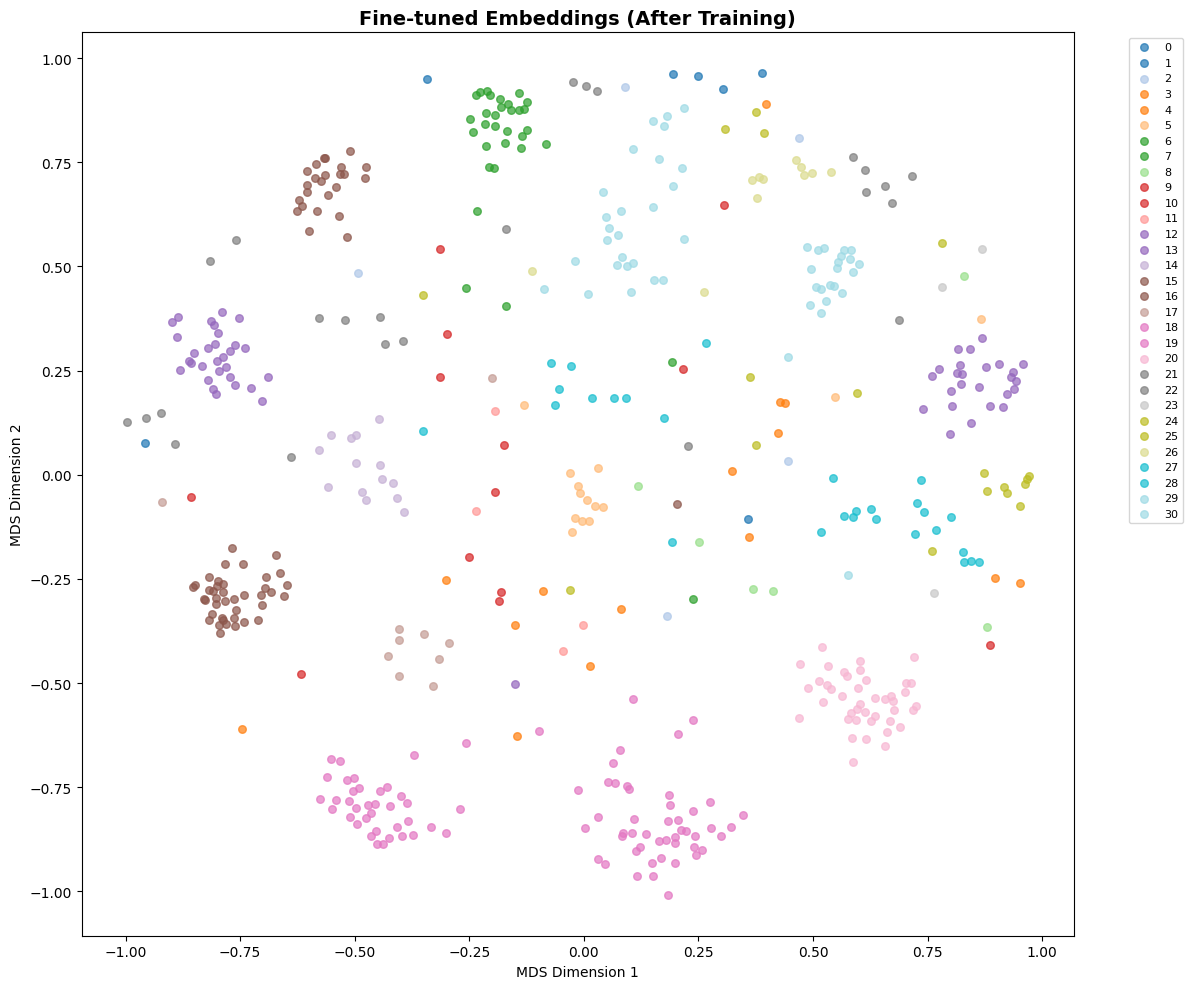

In [ ]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training, Baseline)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "embeddings_mds_baseline.png")
plt.show()

# Log to W&B
wandb.log({"embeddings_mds_baseline": wandb.Image(fig_finetuned)})

In [ ]:
random_idx = np.random.randint(0, len(val_labels))
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
    before_label='BEFORE\nFine-Tuning\n(DINOv3)',
    after_label='AFTER\nFine-Tuning\n(Center + Proxy Anchor)'
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_baseline.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_baseline": wandb.Image(fig),
    "nearest_neighbors_stats_baseline": stats,
})


In [27]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Weighted Sampling

In this intervention, we use a sampler in the dataloader that assigns each sample a weight proportional to the number of images for its jaguar identity divided by the total number of images.


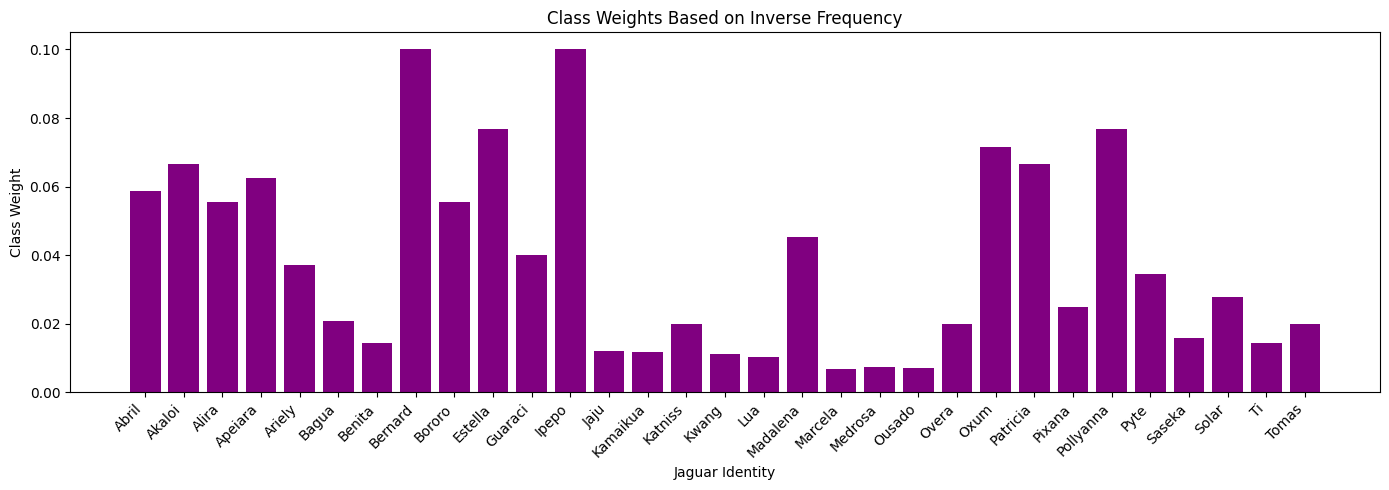

In [ ]:
class_weights = 1.0 / train_counts.values

# plot class weights
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(train_counts.index, class_weights, color='purple')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Class Weight')
ax.set_title('Class Weights Based on Inverse Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "class_weights.png", dpi=150)
plt.show()

# Log to W&B
wandb.log({"class_weights": wandb.Image(fig)})

In [29]:
# Assign a weight to each sample
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=torch.Generator().manual_seed(config['seed'])
)

weighted_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
    sampler=sampler,
    shuffle=False
)

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path, map_location=device))
criterion.load_state_dict(torch.load(criterion_checkpoint_path, map_location=device))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config["num_epochs"],
    eta_min=config["eta_min"]
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss + CenterLoss")
print(f"  Optimizer: AdamW (lr={config['init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: CosineAnnealingLR (T_max={config['num_epochs']}, eta_min={config['eta_min']})")

Training components initialized:
  Loss: ProxyAnchorLoss + CenterLoss
  Optimizer: AdamW (lr=0.005, weight_decay=0.0001)
  Scheduler: CosineAnnealingLR (T_max=200, eta_min=1e-05)


In [ ]:
# Training loop
set_seeds(config['seed'])
weighted_checkpoint_path = CHECKPOINT_PATH / "best_model_weighted.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    weighted_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="weighted",
    checkpoint_path=weighted_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_weighted": best_map,
    "best_epoch_weighted": best_epoch,
    "total_epochs_weighted": len(history['train_loss']),
    "training_time_weighted": training_time
})

table.append([
    "Weighted Sampling",
    best_map,
    best_epoch,
    training_time    
])

All random seeds set to 35 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 7.6263
  Val Loss:   3.1358
  Val mAP:    0.2964 | LR: 5.00e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 3.7294
  Val Loss:   1.5741
  Val mAP:    0.5143 | LR: 5.00e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 1.8670
  Val Loss:   1.3727
  Val mAP:    0.7129 | LR: 5.00e-03
  [New best model saved]

Epoch 4/200


  Train Loss: 1.3249
  Val Loss:   1.3786
  Val mAP:    0.7759 | LR: 5.00e-03
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1184
  Val Loss:   0.9312
  Val mAP:    0.8781 | LR: 4.59e-03
  No improvement. Patience: 6/10

Epoch 38/200


  Train Loss: 0.1331
  Val Loss:   0.9365
  Val mAP:    0.8814 | LR: 4.57e-03
  No improvement. Patience: 7/10

Epoch 39/200


  Train Loss: 0.1222
  Val Loss:   0.9134
  Val mAP:    0.8818 | LR: 4.55e-03
  No improvement. Patience: 8/10

Epoch 40/200


  Train Loss: 0.1176
  Val Loss:   0.9166
  Val mAP:    0.8770 | LR: 4.52e-03
  No improvement. Patience: 9/10

Epoch 41/200


  Train Loss: 0.0984
  Val Loss:   0.9407
  Val mAP:    0.8737 | LR: 4.50e-03
  No improvement. Patience: 10/10

Early stopping triggered after 41 epochs

Training complete!
Best epoch: 31, Val mAP: 0.8823


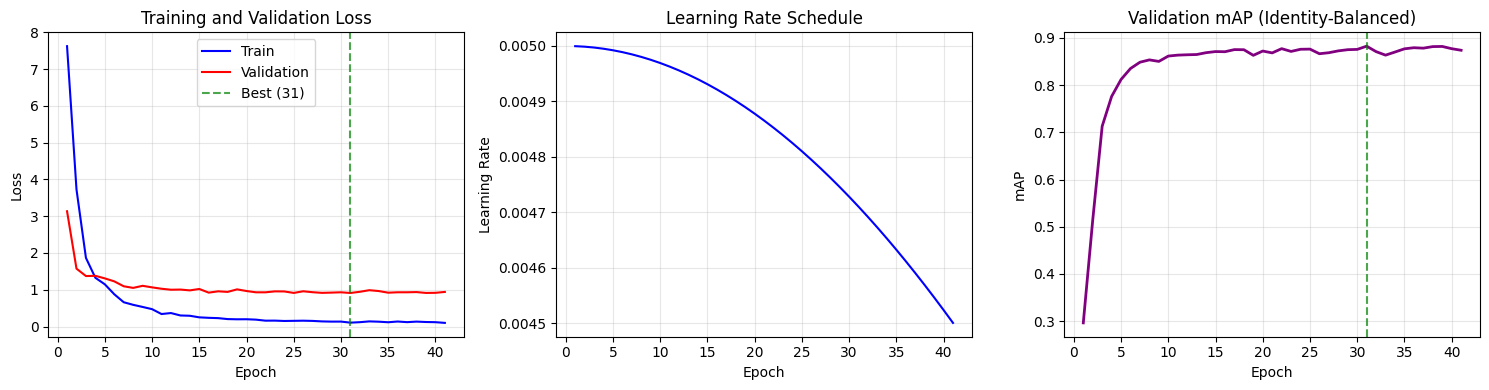

In [32]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_weighted.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_weighted": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(weighted_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 31
  Val Loss: 0.9120
  Val mAP: 0.8823


In [34]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


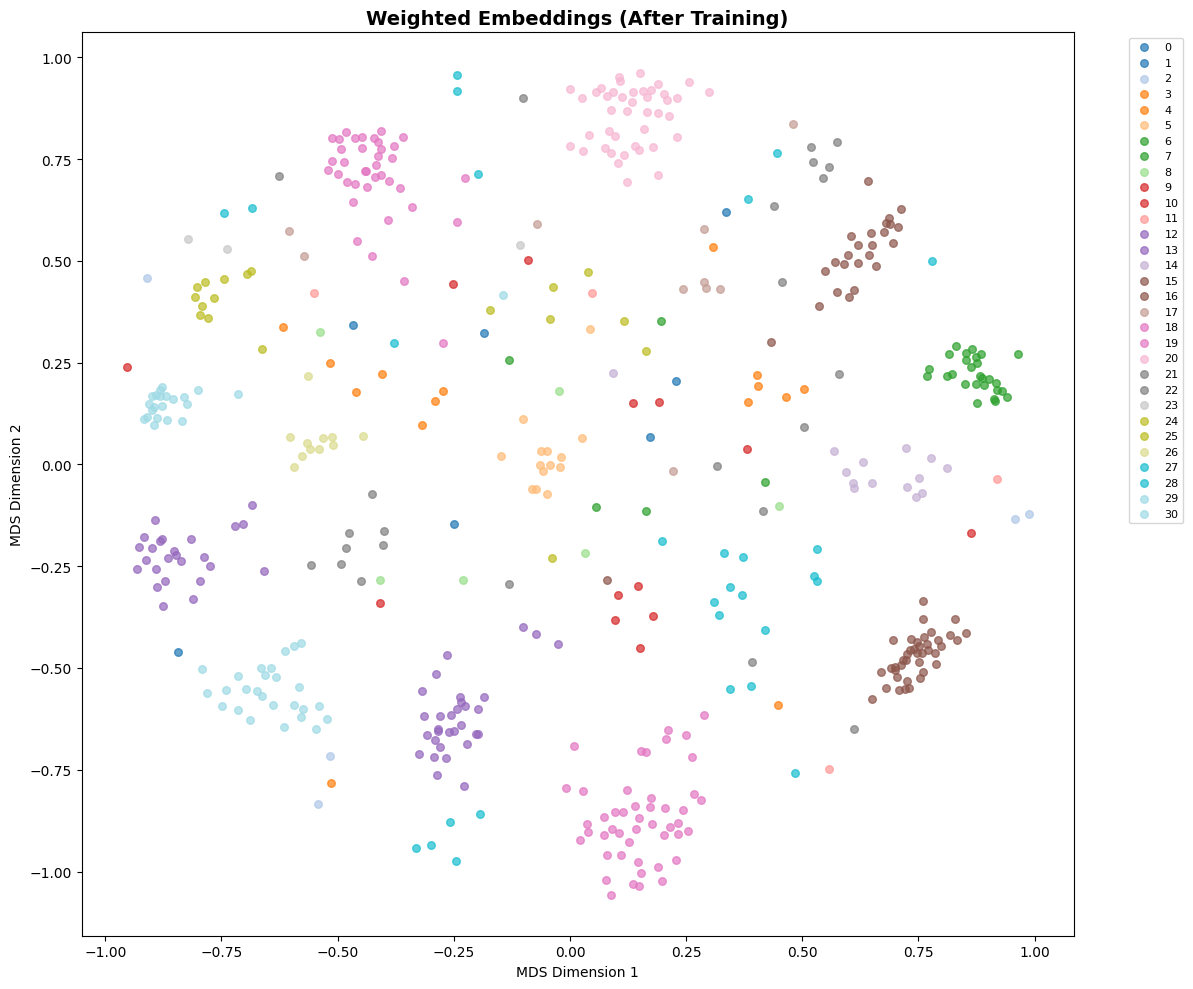

In [ ]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training, Weighted Sampling)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "embeddings_mds_weighted.png")
plt.show()

# Log to W&B
wandb.log({"embeddings_mds_weighted": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
    before_label='BEFORE\nFine-Tuning\n(DINOv3)',
    after_label='AFTER\nFine-Tuning\n(Center + Proxy Anchor)'
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_weighted.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_weighted": wandb.Image(fig),
    "nearest_neighbors_stats_weighted": stats,
})


In [36]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Generate Augmented Samples

In this intervention, we generate new images for underrepresented jaguar identities to ensure that each identity has at least 50 images. The procedure is as follows: for each missing image, we sample an existing image from the same identity, apply data augmentations, save the resulting image, and use it for training. The validation set remains unchanged.

The augmentations are designed to mimic common variations in wildlife images, such as blurring, flips, and rotations.


In [ ]:
augment = transforms.Compose([
    # Randomly flip images horizontally; mimic different side of jaguar
    transforms.RandomHorizontalFlip(),

    # Crop and resize randomly to simulate different distances and framing
    transforms.RandomResizedCrop(dino_dim, scale=(0.85, 1.0)),

    # Small rotations to account for camera angle variation without distorting fur patterns
    transforms.RandomRotation(15),

    # Slight affine transformation: translation and scaling to simulate animal movement
    transforms.RandomAffine(
        degrees=0,           # no extra rotation
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    ),

    # Subtle color changes to mimic lighting variation; avoid distorting natural fur
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.05
    ),

    # Apply slight blur to simulate motion blur or out-of-focus shots
    transforms.GaussianBlur(5, sigma=(0.1, 1.0)),
])

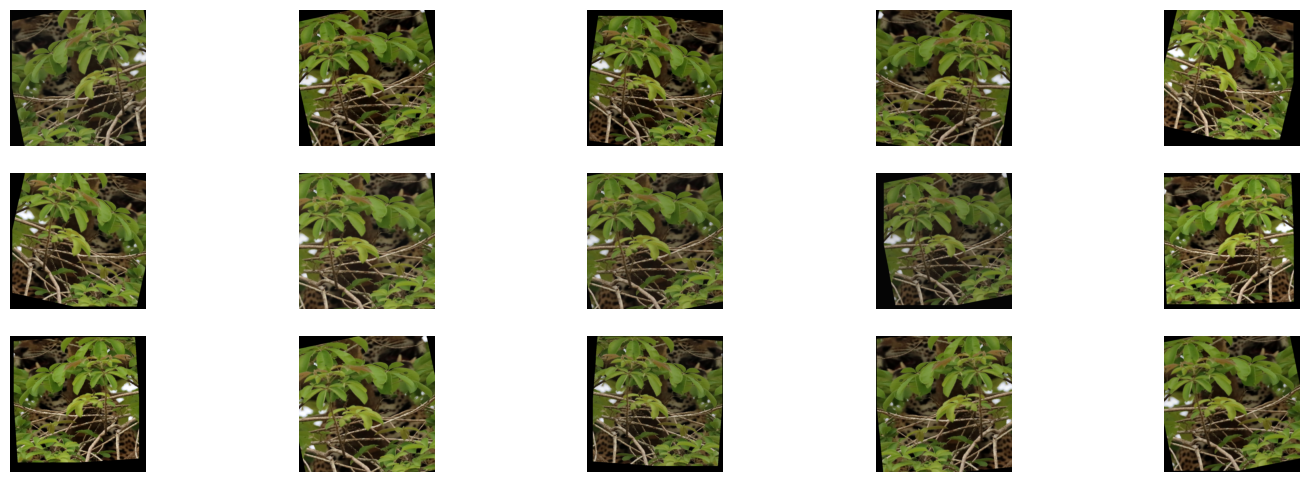

In [ ]:
# Generate multiple augmented versions
image = Image.open(image_paths[0]).convert("RGB")
augmented_images = [augment(image) for _ in range(15)]

# Display them
fig, axes = plt.subplots(3, 5, figsize=(18, 6))
for ax, img in zip(axes.flatten(), augmented_images):
    ax.imshow(img)
    ax.axis("off")

plt.show()

wandb.log({"augmentation_examples_fig": wandb.Image(fig)})

Create augmented images inside own folder.

In [ ]:
augment_dir = OUTPUT_PATH / "augmented_data"
os.makedirs(augment_dir, exist_ok=True)

train_image_paths = np.array(image_paths)[train_mask]

augmented_paths = []
augmented_labels = []

for label in tqdm(range(num_classes), desc="Augmenting classes"):

    mask = train_labels == label
    label_paths = train_image_paths[mask]
    needed = max(0, config["min_images_per_identity"] - len(label_paths))
    
    print(f"Class {label}: {len(label_paths)} samples, need {needed} more")

    for i in range(needed):

        save_path = augment_dir / f"class{label}_aug_{i}.png"

        # To save computation, we only compute images once.
        if not save_path.exists():
            img_path = random.choice(label_paths)
            img = Image.open(img_path).convert("RGBA")

            aug_img = augment(img)
            aug_img.save(save_path)

        augmented_paths.append(save_path)
        augmented_labels.append(label)

augmented_paths = np.array(augmented_paths)
augmented_labels = np.array(augmented_labels)

combined_train_paths = np.concatenate([train_image_paths, augmented_paths])
combined_train_labels = np.concatenate([train_labels, augmented_labels])

combined_train_filenames = np.array([p.name for p in combined_train_paths])

Augmenting classes:  10%|▉         | 3/31 [00:00<00:01, 25.83it/s]

Class 0: 17 samples, need 33 more
Class 1: 15 samples, need 35 more
Class 2: 18 samples, need 32 more
Class 3: 16 samples, need 34 more
Class 4: 27 samples, need 23 more
Class 5: 48 samples, need 2 more
Class 6: 69 samples, need 0 more
Class 7: 10 samples, need 40 more


Augmenting classes:  39%|███▊      | 12/31 [00:00<00:00, 33.75it/s]

Class 8: 18 samples, need 32 more
Class 9: 13 samples, need 37 more
Class 10: 25 samples, need 25 more
Class 11: 10 samples, need 40 more
Class 12: 83 samples, need 0 more
Class 13: 84 samples, need 0 more
Class 14: 50 samples, need 0 more
Class 15: 90 samples, need 0 more
Class 16: 96 samples, need 0 more
Class 17: 22 samples, need 28 more
Class 18: 147 samples, need 0 more
Class 19: 136 samples, need 0 more
Class 20: 143 samples, need 0 more
Class 21: 50 samples, need 0 more
Class 22: 14 samples, need 36 more
Class 23: 15 samples, need 35 more


Augmenting classes: 100%|██████████| 31/31 [00:00<00:00, 57.17it/s]

Class 24: 40 samples, need 10 more
Class 25: 13 samples, need 37 more
Class 26: 29 samples, need 21 more
Class 27: 63 samples, need 0 more
Class 28: 36 samples, need 14 more
Class 29: 69 samples, need 0 more
Class 30: 50 samples, need 0 more


In [ ]:
combined_train_image_dataset = BlurImageDataset(
    combined_train_paths,
    preprocess_fn=dino_preprocess
)
combined_train_image_loader = DataLoader(
    combined_train_image_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(combined_train_image_loader)} batches")

Image DataLoader created with 64 batches


We embed the original and augmented images once to reduce computational cost.


In [ ]:
combined_cache_path = OUTPUT_PATH / "dino_blur_combined_embeddings.npz"

combined_train_embeddings = get_embeddings(
    model=dino,
    combined_cache_path=combined_cache_path,
    combined_train_image_loader=combined_train_image_loader,
    combined_train_filenames=combined_train_filenames,
    device=device
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/balancing/dino_blur_combined_embeddings.npz
Embeddings shape: (2030, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


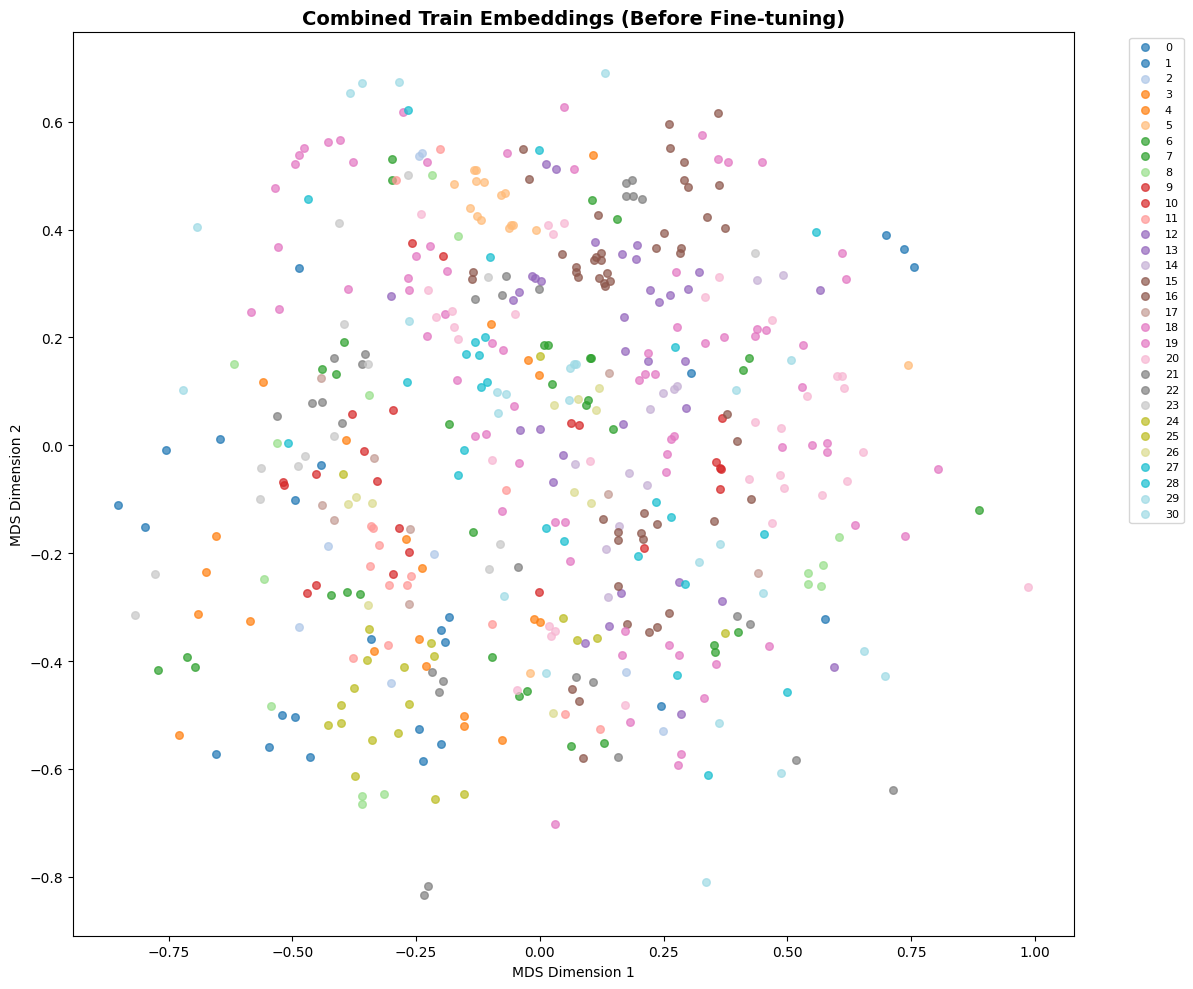

In [44]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    combined_train_embeddings,
    combined_train_labels,
    "Combined Train Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "combined_train_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"combined_train_embeddings_mds": wandb.Image(fig)})

In [45]:
combined_emb_train_dataset = EmbeddingDataset(
    combined_train_embeddings,
    combined_train_labels
)

combined_emb_train_loader = create_deterministic_training_dataloader(
    combined_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
)

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path, map_location=device))
criterion.load_state_dict(torch.load(criterion_checkpoint_path, map_location=device))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config["num_epochs"],
    eta_min=config["eta_min"]
)

print("Training components initialized:")
print(f"  Optimizer: AdamW (lr={config['init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: CosineAnnealingLR (T_max={config['num_epochs']}, eta_min={config['eta_min']})")

Training components initialized:
  Loss: ProxyAnchorLoss + CenterLoss
  Optimizer: AdamW (lr=0.005, weight_decay=0.0001)
  Scheduler: CosineAnnealingLR (T_max=200, eta_min=1e-05)


In [ ]:
# Training loop
set_seeds(config['seed'])
generated_checkpoint_path = CHECKPOINT_PATH / "best_model_balanced.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    combined_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="generated",
    checkpoint_path=generated_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_generated": best_map,
    "best_epoch_generated": best_epoch,
    "total_epochs_generated": len(history['train_loss']),
    "training_time_generated": training_time
})

table.append([
    "Generated Augmentations",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 35 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 7.2916
  Val Loss:   2.1227
  Val mAP:    0.3327 | LR: 5.00e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 3.4312
  Val Loss:   1.5460
  Val mAP:    0.5855 | LR: 5.00e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 2.2010
  Val Loss:   1.3199
  Val mAP:    0.7408 | LR: 5.00e-03
  [New best model saved]

Epoch 4/200


  Train Loss: 1.5076
  Val Loss:   1.2278
  Val mAP:    0.7960 | LR: 5.00e-03
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1221
  Val Loss:   0.8522
  Val mAP:    0.8875 | LR: 4.73e-03
  No improvement. Patience: 6/10

Epoch 31/200


  Train Loss: 0.1137
  Val Loss:   0.9024
  Val mAP:    0.8796 | LR: 4.71e-03
  No improvement. Patience: 7/10

Epoch 32/200


  Train Loss: 0.1276
  Val Loss:   0.9114
  Val mAP:    0.8755 | LR: 4.69e-03
  No improvement. Patience: 8/10

Epoch 33/200


  Train Loss: 0.1588
  Val Loss:   0.8807
  Val mAP:    0.8871 | LR: 4.67e-03
  No improvement. Patience: 9/10

Epoch 34/200


  Train Loss: 0.1555
  Val Loss:   0.8738
  Val mAP:    0.8892 | LR: 4.65e-03
  No improvement. Patience: 10/10

Early stopping triggered after 34 epochs

Training complete!
Best epoch: 24, Val mAP: 0.9013


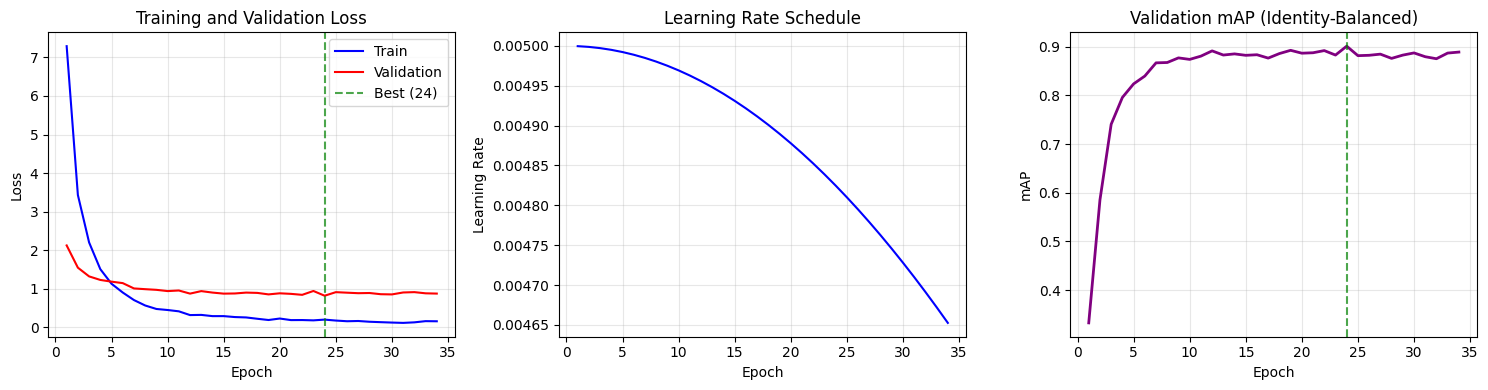

In [ ]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_generated.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_generated": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(generated_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 24
  Val Loss: 0.8183
  Val mAP: 0.9013


In [50]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


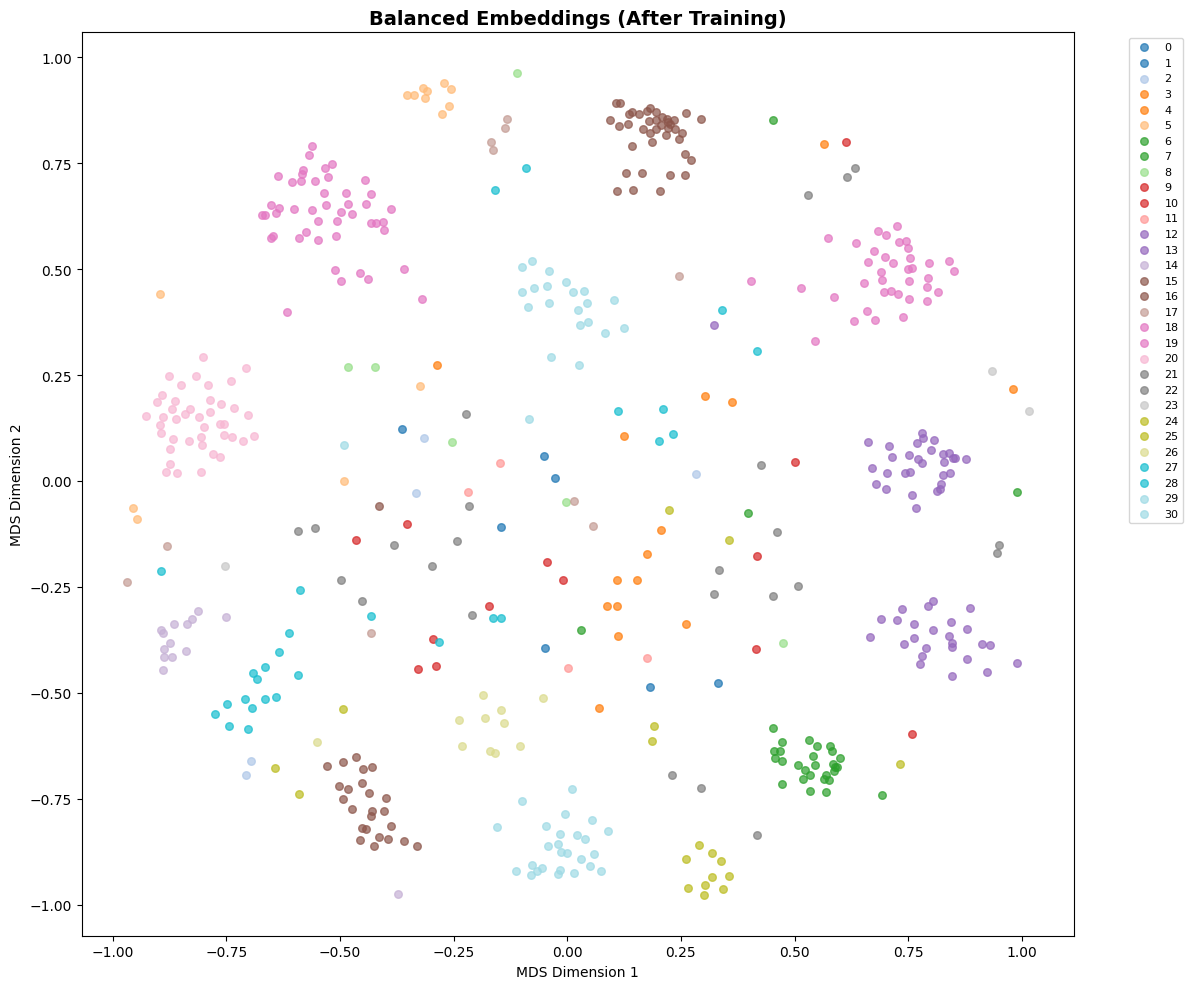

In [ ]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Combined Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "embeddings_mds_generated.png")
plt.show()

# Log to W&B
wandb.log({"embeddings_mds_generated": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
    before_label='BEFORE\nFine-Tuning\n(DINOv3)',
    after_label='AFTER\nFine-Tuning\n(Center + Proxy Anchor)'
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_generated.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_generated": wandb.Image(fig),
    "nearest_neighbors_stats_generated": stats,
})


In [52]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Weighted Sampling + Augmentation

We now combine the previous approaches. Specifically, we introduce a sampler that uses the class weights from the first intervention, while applying the **augmentations from the second intervention** on the fly during image loading. This increases dataset diversity and encourages the model to focus on meaningful patterns when generating embeddings for jaguar identities.

Using weighted sampling alone would repeatedly present the same images from underrepresented classes, which could cause the model to overfit these limited samples. By combining sampling with on-the-fly augmentation, the model sees varied versions of these images, improving generalization for underrepresented identities.

Since new images are generated in each batch through augmentation, embeddings cannot be precomputed. Therefore, the backbone and embedding projection model must be combined and trained end-to-end. This significantly increases training time, as images need to be loaded and processed at every step.

To reduce loading time, we first resize all images and store them in a separate directory. Image loading dominates the embedding time, so using smaller images should substantially reduce training time. However, this preprocessing step may also influence the effectiveness of the applied augmentations.


In [ ]:
# Iterate over images. resize and output in own directory if not already done
augmented_dir = OUTPUT_PATH / "resized_images"
augmented_dir.mkdir(parents=True, exist_ok=True)

dino_input_size = dino_config["input_size"]

for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Augmenting images"):
    filename = idx
    input_path = DATA_PATH / "train" / filename
    output_path = augmented_dir / filename

    # Resize only once to save time
    if output_path.exists():
        continue

    image = cv2.imread(input_path, cv2.IMREAD_UNCHANGED)
    if image is None:
        print(f"Warning: Could not read image {input_path}")
        continue

    rgb = image[:, :, :3]
    alpha = image[:, :, 3]

    # We use blur from the BlurImageDataset
    blurred = cv2.GaussianBlur(rgb, (0, 0), sigmaX=10, sigmaY=10)

    mask = alpha == 0
    rgb = rgb.copy()
    rgb[mask] = blurred[mask]
    
    image = np.concatenate([rgb, alpha[:, :, np.newaxis]], axis=2)
    resized_image = cv2.resize(image, (dino_input_size[2], dino_input_size[1]))

    # Save augmented image
    cv2.imwrite(output_path, resized_image)

resized_image_paths = np.array([augmented_dir / fn for fn in train_df.index.astype(str)])

resized_train_image_paths = resized_image_paths[train_mask]
resized_val_image_paths = resized_image_paths[~train_mask]

Augmenting images: 100%|██████████| 1895/1895 [24:49<00:00,  1.27it/s] 


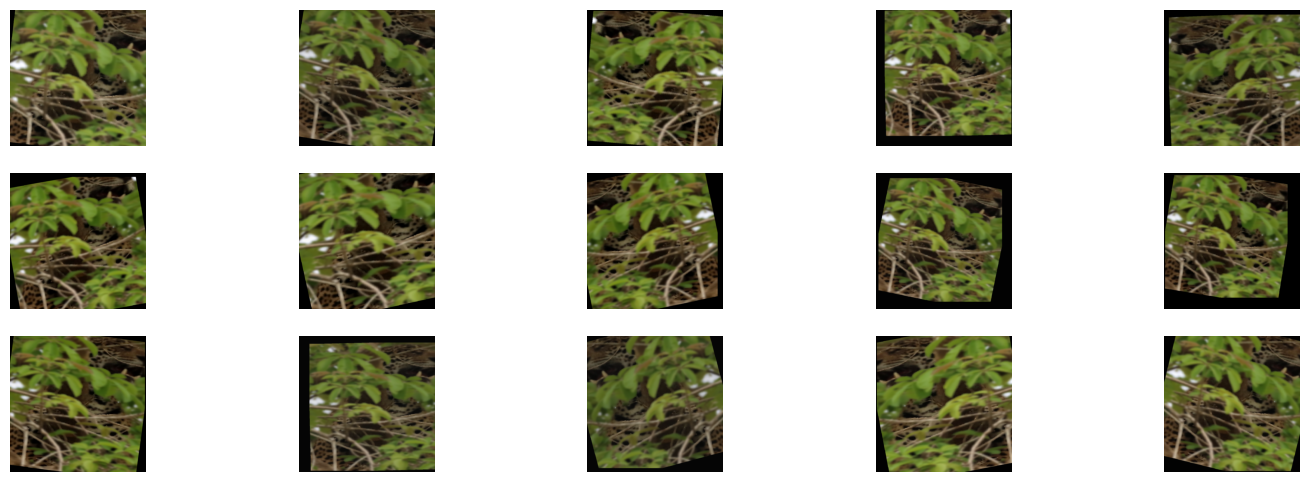

In [54]:
# Generate multiple augmented versions
image = Image.open(resized_image_paths[0]).convert("RGB")
augmented_images = [augment(image) for _ in range(15)]

# Display them
fig, axes = plt.subplots(3, 5, figsize=(18, 6))
for ax, img in zip(axes.flatten(), augmented_images):
    ax.imshow(img)
    ax.axis("off")

plt.show()

Define a combined model that integrates two models, where the first model is used without gradient updates.


In [ ]:
class CombinedModel(nn.Module):
    """
    A simple wrapper to combine the frozen DINO model with the trainable projection head.
    """
    def __init__(self, model_a, model_b):
        super().__init__()
        self.model_a = model_a
        self.model_b = model_b

    def forward(self, x):
        with torch.no_grad():        # ensures model_a stays frozen during forward
            features = self.model_a(x)
        output = self.model_b(features)
        return output

In [ ]:
train_image_dataset = ImageDataset(
    resized_train_image_paths,
    labels=train_labels,
    transform_fn=augment,
    preprocess_fn=dino_preprocess
)
val_image_dataset = ImageDataset(
    resized_val_image_paths,
    labels=val_labels,
    transform_fn=augment,
    preprocess_fn=dino_preprocess
)

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=torch.Generator().manual_seed(config['seed'])
)

train_image_loader = create_deterministic_training_dataloader(
    train_image_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    sampler=sampler,
    shuffle=False,
    pin_memory=True,
)

val_image_loader = DataLoader(
    val_image_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

print(f"Train Image DataLoader created with {len(train_image_loader)} batches")
print(f"Validation Image DataLoader created with {len(val_image_loader)} batches")

Train Image DataLoader created with 48 batches
Validation Image DataLoader created with 12 batches


In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path, map_location=device))
criterion.load_state_dict(torch.load(criterion_checkpoint_path, map_location=device))

# freeze dino parameters
for param in dino.parameters():
    param.requires_grad = False

# combined model
combined_model = CombinedModel(dino, model)

wandb.log({"num_combined_params": sum(p.numel() for p in combined_model.parameters())})

optimizer = torch.optim.AdamW(
    list(combined_model.parameters()) + list(criterion.parameters()),
    lr=config["init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config["num_epochs"],
    eta_min=config["eta_min"]
)

print("Training components initialized:")
print(f"  Optimizer: AdamW (lr={config['init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: CosineAnnealingLR (T_max={config['num_epochs']}, eta_min={config['eta_min']})")

Training components initialized:
  Loss: ProxyAnchorLoss + CenterLoss
  Optimizer: AdamW (lr=0.005, weight_decay=0.0001)
  Scheduler: CosineAnnealingLR (T_max=200, eta_min=1e-05)


In [59]:
combined_model.eval()
with torch.no_grad():
    img = Image.open(resized_train_image_paths[0]).convert("RGB")
    img_tensor = dino_preprocess(img).unsqueeze(0).to(device)
    dummy_output = combined_model(img_tensor)
    print(f"Combined model output shape: {dummy_output.shape}")

Combined model output shape: torch.Size([1, 256])


In [ ]:
# Training loop
set_seeds(config['seed'])
weighted_augmented_checkpoint_path = CHECKPOINT_PATH / "best_model_weighted_augmented.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    combined_model, 
    train_image_loader, 
    val_image_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="weighted_augmented",
    checkpoint_path=weighted_augmented_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_weighted_augmented": best_map,
    "best_epoch_weighted_augmented": best_epoch,
    "total_epochs_weighted_augmented": len(history['train_loss']),
    "training_time_weighted_augmented": training_time
})

table.append([
    "Weighted Sampling + Augmentations",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 35 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 7.9793
  Val Loss:   3.3125
  Val mAP:    0.3220 | LR: 5.00e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 4.1538
  Val Loss:   1.6314
  Val mAP:    0.4762 | LR: 5.00e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 2.2619
  Val Loss:   1.4280
  Val mAP:    0.6444 | LR: 5.00e-03
  [New best model saved]

Epoch 4/200


  Train Loss: 1.7181
  Val Loss:   1.2000
  Val mAP:    0.7609 | LR: 5.00e-03
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1879
  Val Loss:   0.8164
  Val mAP:    0.8812 | LR: 4.35e-03
  No improvement. Patience: 6/10

Epoch 48/200


  Train Loss: 0.2032
  Val Loss:   0.8038
  Val mAP:    0.8852 | LR: 4.32e-03
  No improvement. Patience: 7/10

Epoch 49/200


  Train Loss: 0.2041
  Val Loss:   0.7947
  Val mAP:    0.8913 | LR: 4.30e-03
  No improvement. Patience: 8/10

Epoch 50/200


  Train Loss: 0.1687
  Val Loss:   0.7228
  Val mAP:    0.8840 | LR: 4.27e-03
  No improvement. Patience: 9/10

Epoch 51/200


  Train Loss: 0.1531
  Val Loss:   0.7450
  Val mAP:    0.8942 | LR: 4.24e-03
  No improvement. Patience: 10/10

Early stopping triggered after 51 epochs

Training complete!
Best epoch: 41, Val mAP: 0.8980


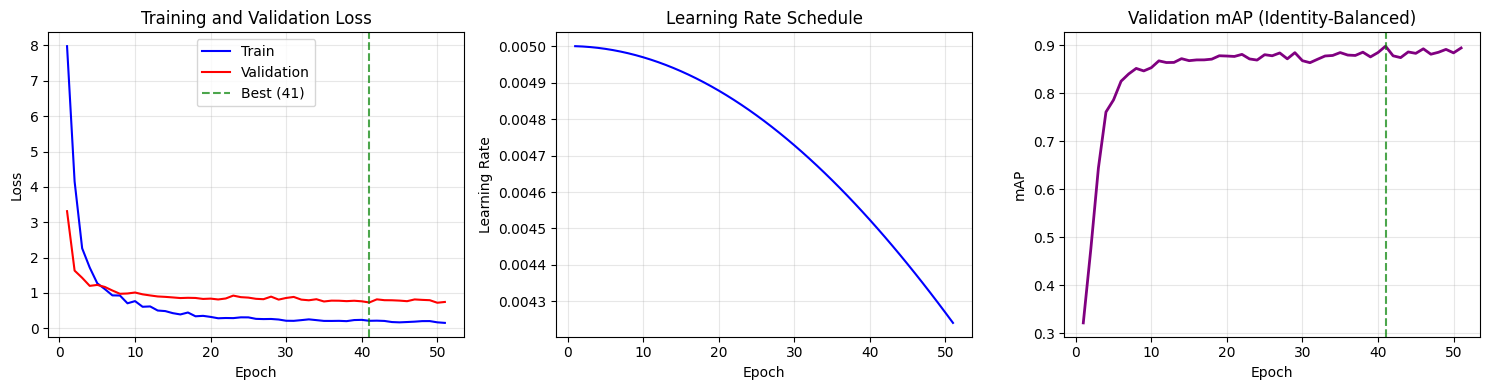

In [61]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_weighted_augmented.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_weighted_augmented": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(weighted_augmented_checkpoint_path, map_location=device, weights_only=False)
combined_model.load_state_dict(checkpoint['model_state_dict'])
combined_model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 41
  Val Loss: 0.7305
  Val mAP: 0.8980


In [ ]:
# Save projection head separately for embedding extraction
final_projection_head_path = CHECKPOINT_PATH / "weighted_augmented_projection_head.pth"
model = combined_model.model_b
torch.save(model.state_dict(), final_projection_head_path)
print(f"Final projection head saved to {final_projection_head_path}")

In [63]:
# Extract fine-tuned embeddings for training data
combined_model.eval()
with torch.no_grad():
    finetuned_embeddings = []
    for imgs in tqdm(image_loader, desc="Extracting embeddings with combined model"):
        imgs = imgs.to(device)
        embeddings = combined_model(imgs)
        finetuned_embeddings.append(embeddings.cpu().numpy())
    finetuned_embeddings = np.concatenate(finetuned_embeddings, axis=0)
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Extracting embeddings with combined model: 100%|██████████| 60/60 [03:52<00:00,  3.87s/it]

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


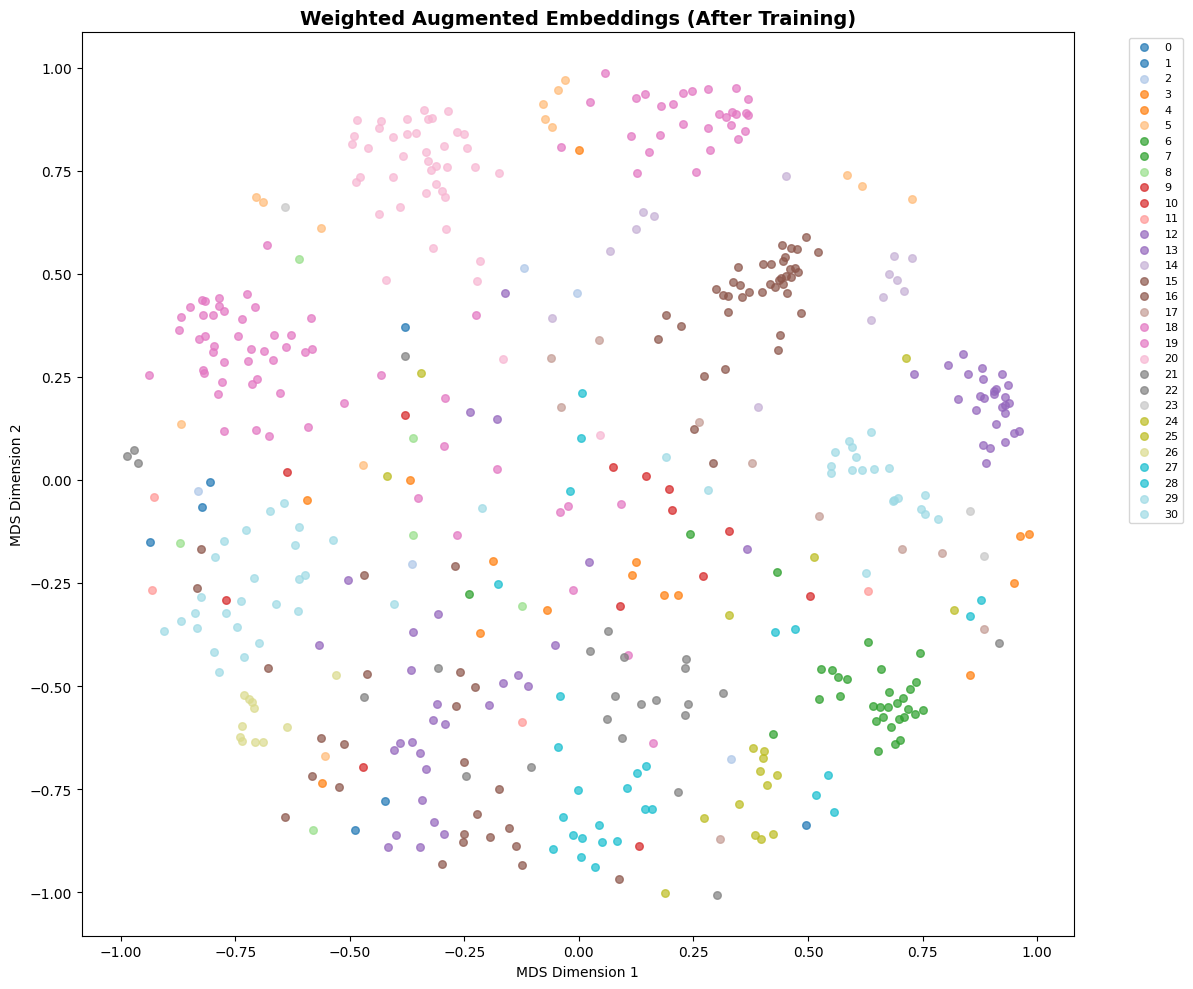

In [64]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Weighted Augmented Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "embeddings_mds_weighted_augmented.png")
plt.show()

# Log to W&B
wandb.log({"embeddings_mds_weighted_augmented": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
    before_label='BEFORE\nFine-Tuning\n(DINOv3)',
    after_label='AFTER\nFine-Tuning\n(Center + Proxy Anchor)'
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_weighted_augmented.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_weighted_augmented": wandb.Image(fig),
    "nearest_neighbors_stats_weighted_augmented": stats,
})


In [65]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [66]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+------------+------------+------------+------------+----------------------+
| Strategy   |   Baseline |   Weighted |   Balanced |   Weighted Augmented |
+============+============+============+============+======================+
| val_mAP    |     0.8873 |     0.8823 |     0.9013 |                0.898 |
+------------+------------+------------+------------+----------------------+
| num_epochs |    30      |    41      |    34      |               51     |
+------------+------------+------------+------------+----------------------+


In [ ]:
# create df from table and log to W&B
df = pd.DataFrame(table[1:], columns=table[0])
print(df)

wandb.log({"experiment_summary": wandb.Table(dataframe=df)})

## Submission

In [ ]:
submission_model = "cosineannealinglr"

submission_dict = {
    "baseline": baseline_checkpoint_path,
    "weighted": weighted_checkpoint_path,
    "generated": generated_checkpoint_path,
    "weighted_augmented": weighted_augmented_checkpoint_path,
}

if submission_model not in submission_dict:
    raise ValueError(f"Invalid submission model: {submission_model}")

checkpoint_path = submission_dict[submission_model]

wandb.log({"submission_type": submission_model})

In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

FileNotFoundError: [Errno 2] No such file or directory: '/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/balancing/best_model.pth'

In [ ]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [ ]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(
        test_image_paths,
        preprocess_fn=dino_preprocess
    ),
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    model=dino,
    data_loader=test_loader,
    device=device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: 100%|██████████| 12/12 [00:59<00:00,  4.96s/it]

Test embeddings shape: (371, 768)


In [ ]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [ ]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...
Similarity matrix shape: (371, 371) Sim range: [0.0016, 1.0000]


Computing similarities: 100%|██████████| 137270/137270 [00:03<00:00, 38067.04it/s]


Similarity statistics:
  Min: 0.0016
  Max: 1.0000
  Mean: 0.8596
  Std: 0.1542


In [ ]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.643482
1       1    0.882659
2       2    0.765042
3       3    0.810544
4       4    0.809093
5       5    0.638782
6       6    0.866316
7       7    0.840366
8       8    0.767672
9       9    0.810581

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [ ]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/reranking/submission.csv
File size: 2217.3 KB


## Artifacts

In [ ]:
# Save model as W&B artifact
for key in submission_dict:
    checkpoint_path = submission_dict[key]
    model_artifact = wandb.Artifact(
        name=f"model-{key}",
        type="model",
        description="Center + ProxyAnchor fine-tuned MegaDescriptor model for jaguar re-identification with class intervention: " + key
    )
    model_artifact.add_file(checkpoint_path)
    wandb.log_artifact(model_artifact)

print("Model artifacts saved to W&B")

Model artifacts saved to W&B


In [ ]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description=f"Competition submission file for {submission_model}"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [ ]:
wandb.finish()

best_epoch_baseline,▁
best_epoch_bg_image,▁
best_epoch_blur_bg,▁
best_epoch_const_bg,▁
best_epoch_extend_fg,▁
best_epoch_noise_bg,▁
best_epoch_sample_fg,▁
epoch,▃▄▅▅▇▁▂▂▄▄▅▆▇▇█▂▂▃▃▄▅▅▇█▁▂▃▃▇▇▁▃▆▇▁▆▇▄▄▆
final_val_mAP_baseline,▁
final_val_mAP_bg_image,▁
+21,...
